# Additional Task 1: MIRAGE Collection

1. Process the collection: collect all passages, generate qrels files.
2. Apply the same set of analyses and methods (TF-IDF, BM25, evaluation).
3. Compare results on both collections (WikiIR vs MIRAGE).

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import spacy
from nltk.stem import PorterStemmer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import ir_measures
from ir_measures import AP, P, nDCG
from datasets import load_dataset
import matplotlib.pyplot as plt

/Users/maksimpiskaev/Проекты/IR/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка и обработка коллекции MIRAGE

MIRAGE содержит 7560 Q/A пар и 37800 контекстных пулов из Wikipedia-based QA бенчмарков (PopQA, NaturalQA, TriviaQA, IfQA, DROP).
Каждый запрос имеет пул из 5 пассажей с метками `support` (1 = релевантный, 0 = нерелевантный).

In [2]:
ds = load_dataset("nlpai-lab/mirage")
data = ds["train"]
print(f"Запросов: {len(data)}")
print(f"Колонки: {data.column_names}")


Запросов: 7560
Колонки: ['source', 'query_id', 'query', 'doc_name', 'answer', 'doc_url', 'num_doc_labels', 'doc_pool', 'oracle']


In [ ]:
# Сбор всех уникальных пассажей и генерация doc_id
passage_to_id = {}
passages = []  
doc_counter = 0

for row in data:
    for chunk in row["doc_pool"]["doc_chunk"]:
        if chunk not in passage_to_id:
            passage_to_id[chunk] = f"D{doc_counter}"
            passages.append((f"D{doc_counter}", chunk))
            doc_counter += 1

documents = pd.DataFrame(passages, columns=["doc_id", "text"])
print(f"Уникальных пассажей (документов): {len(documents)}")
print(f"Средняя длина пассажа: {documents['text'].str.split().str.len().mean():.1f} слов")
documents.head()

Уникальных пассажей (документов): 36864
Средняя длина пассажа: 196.1 слов


,doc_id,text
0,D0,"Scottish printer, journalist and poet\nJohn Ma..."
1,D1,"Mayne's ""Siller Gun"" was based on a Dumfries w..."
2,D2,British lawyer (1828–1917)\nJohn Dawson Mayne ...
3,D3,"Mayne served as the Professor of law, logic an..."
4,D4,"Annie's first husband's name is unknown, but s..."


In [4]:
# Генерация qrels
qrels_rows = []

for row in data:
    qid = row["query_id"]
    pool = row["doc_pool"]
    for chunk, support in zip(pool["doc_chunk"], pool["support"]):
        doc_id = passage_to_id[chunk]
        qrels_rows.append({
            "query_id": qid,
            "iter": 0,
            "doc_id": doc_id,
            "relevance": support,
        })

qrels = pd.DataFrame(qrels_rows)
print(f"Записей в qrels: {len(qrels)}")
print(f"Релевантных: {(qrels['relevance'] == 1).sum()}, нерелевантных: {(qrels['relevance'] == 0).sum()}")
qrels.head()

Записей в qrels: 37800
Релевантных: 9268, нерелевантных: 28532


,query_id,iter,doc_id,relevance
0,ce40d2c4-f403-4736-ace1-7fca9c722aba,0,D0,1
1,ce40d2c4-f403-4736-ace1-7fca9c722aba,0,D1,0
2,ce40d2c4-f403-4736-ace1-7fca9c722aba,0,D2,0
3,ce40d2c4-f403-4736-ace1-7fca9c722aba,0,D3,0
4,ce40d2c4-f403-4736-ace1-7fca9c722aba,0,D4,0


In [5]:
# Сохранение qrels в TREC формате
MIRAGE_DIR = Path("mirage_data")
MIRAGE_DIR.mkdir(exist_ok=True)

qrels_path = MIRAGE_DIR / "qrels"
with open(qrels_path, "w") as f:
    for _, row in qrels.iterrows():
        f.write(f"{row['query_id']}\t{row['iter']}\t{row['doc_id']}\t{row['relevance']}\n")

print(f"qrels сохранены: {qrels_path}")

# Сбор запросов
queries = pd.DataFrame([
    {"query_id": row["query_id"], "text": row["query"]}
    for row in data
])
print(f"Запросов: {len(queries)}")
queries.head()

qrels сохранены: mirage_data/qrels
Запросов: 7560


,query_id,text
0,ce40d2c4-f403-4736-ace1-7fca9c722aba,What is John Mayne's occupation?
1,647d126c-564b-46c6-a8a7-6eda23449e10,What is Kathy Saltzman's occupation?
2,e8acd86c-e651-47fa-8440-2eb759a5f5ea,What is Eleanor Davis's occupation?
3,4d5a3c5c-4b7c-4633-a9f9-a39d9e885344,"What is William Murray, 1st Earl of Mansfield'..."
4,5bede7e0-5a07-480a-ba01-b2e7adffd4e2,What is Þorsteinn Bachmann's occupation?


## 2. Базовая статистика по запросам

In [6]:
n_queries = len(queries)
queries["word_count"] = queries["text"].str.split().str.len()

print(f"Количество запросов: {n_queries}")
print(f"Длина запросов (слова): min={queries['word_count'].min()}, "
      f"max={queries['word_count'].max()}, "
      f"mean={queries['word_count'].mean():.2f}, "
      f"median={queries['word_count'].median():.1f}")

rel_per_query = qrels[qrels["relevance"] >= 1].groupby("query_id").size()
print(f"Релевантных документов на запрос: min={rel_per_query.min()}, "
      f"max={rel_per_query.max()}, "
      f"mean={rel_per_query.mean():.2f}, "
      f"median={rel_per_query.median():.1f}")

Количество запросов: 7560
Длина запросов (слова): min=3, max=54, mean=8.74, median=8.0
Релевантных документов на запрос: min=1, max=5, mean=1.23, median=1.0


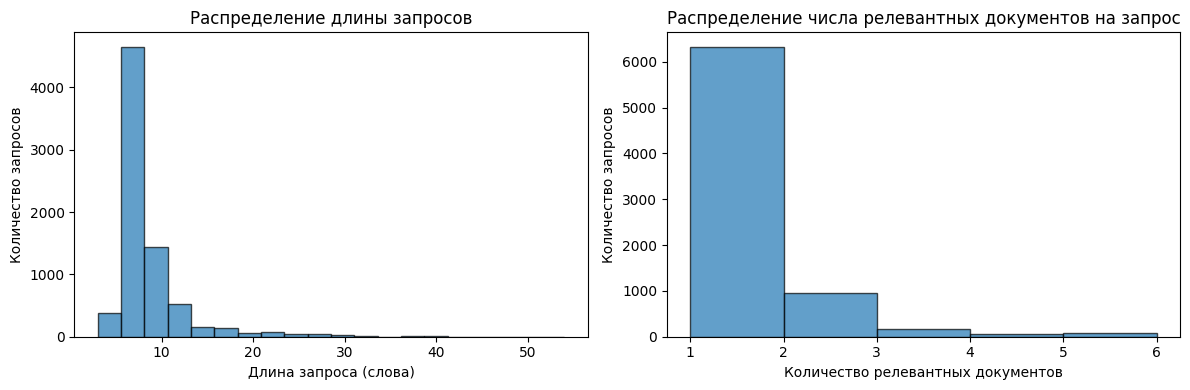

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(queries["word_count"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Длина запроса (слова)")
axes[0].set_ylabel("Количество запросов")
axes[0].set_title("Распределение длины запросов")

axes[1].hist(rel_per_query, bins=range(1, rel_per_query.max() + 2), edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Количество релевантных документов")
axes[1].set_ylabel("Количество запросов")
axes[1].set_title("Распределение числа релевантных документов на запрос")

plt.tight_layout()
plt.show()

In [8]:
# Распределение по источникам
source_counts = pd.Series([row["source"] for row in data]).value_counts()
print("Распределение по источникам:")
print(source_counts)

Распределение по источникам:
naturalqa    3578
popqa        3075
triviaqa      584
ifqa          248
drop           75
Name: count, dtype: int64


## 3. Морфологическая обработка коллекции

In [9]:
stemmer = PorterStemmer()

def stem_text(text: str) -> str:
    return " ".join(stemmer.stem(w) for w in text.split())

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def lemmatize_text(text: str) -> str:
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)

In [10]:
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

docs_original = documents["text"].tolist()
N_DOCS = len(docs_original)
LEMMA_N_PROCESS = max(1, (os.cpu_count() or 1) - 1)


def load_or_build(name, cache_path, builder):
    if cache_path.exists():
        docs = pd.read_pickle(cache_path)
        if len(docs) == N_DOCS:
            print(f"{name}: loaded from cache")
            return docs
    print(f"{name}: building...")
    docs = builder()
    pd.to_pickle(docs, cache_path)
    return docs


docs_stemmed = load_or_build(
    "Stemmed",
    CACHE_DIR / "mirage_docs_stemmed.pkl",
    lambda: [stem_text(t) for t in tqdm(docs_original, desc="Stemming")],
)

docs_lemmatized = load_or_build(
    "Lemmatized",
    CACHE_DIR / "mirage_docs_lemmatized.pkl",
    lambda: [
        " ".join(token.lemma_ for token in doc)
        for doc in tqdm(
            nlp.pipe(docs_original, batch_size=2000, n_process=LEMMA_N_PROCESS),
            total=N_DOCS,
            desc=f"Lemmatizing ({LEMMA_N_PROCESS} proc)",
        )
    ],
)

print(f"original={N_DOCS}, stemmed={len(docs_stemmed)}, lemmatized={len(docs_lemmatized)}")

Stemmed: building...


Stemming: 100%|██████████| 36864/36864 [00:34<00:00, 1057.37it/s]


Lemmatized: building...


Lemmatizing (7 proc): 100%|██████████| 36864/36864 [06:21<00:00, 96.60it/s]  


original=36864, stemmed=36864, lemmatized=36864


In [11]:
# Подготовка вариантов запросов
queries_original = queries["text"].tolist()
queries_stemmed = [stem_text(t) for t in queries_original]
queries_lemmatized = [
    " ".join(token.lemma_ for token in doc)
    for doc in nlp.pipe(queries_original, batch_size=256)
]

query_ids = queries["query_id"].tolist()
doc_ids = documents["doc_id"].tolist()

collection_variants = {
    "original": {"docs": docs_original, "queries": queries_original},
    "stemmed": {"docs": docs_stemmed, "queries": queries_stemmed},
    "lemmatized": {"docs": docs_lemmatized, "queries": queries_lemmatized},
}

## 4. TF-IDF и BM25 на трёх вариантах коллекции

In [12]:
TOP_K = 100

RUNS_DIR = Path("runs_mirage")
RUNS_DIR.mkdir(exist_ok=True)


def save_trec_run(query_ids, doc_ids, all_scores, run_id, top_k=TOP_K):
    lines = []
    for row_idx, qid in enumerate(query_ids):
        scores = all_scores[row_idx]
        top_indices = np.argsort(scores)[::-1][:top_k]
        for rank, doc_idx in enumerate(top_indices, start=1):
            lines.append(
                f"{qid} Q0 {doc_ids[doc_idx]} {rank} {scores[doc_idx]:.6f} {run_id}"
            )
    path = RUNS_DIR / f"{run_id}.txt"
    with open(path, "w") as f:
        f.write("\n".join(lines) + "\n")
    print(f"Saved: {path} ({len(lines)} lines)")
    return path


def run_tfidf_experiment(variant_name, docs, queries_list):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(docs)
    start = time.perf_counter()
    query_vectors = vectorizer.transform(queries_list)
    scores = cosine_similarity(query_vectors, tfidf_matrix)
    query_time = time.perf_counter() - start
    run_id = f"mirage_tfidf_{variant_name}"
    run_path = save_trec_run(query_ids, doc_ids, scores, run_id)
    return {"model": "tfidf", "variant": variant_name, "query_time_sec": query_time, "run_path": str(run_path)}


def run_bm25_experiment(variant_name, docs, queries_list):
    bm25 = BM25Okapi([doc.split() for doc in docs])
    start = time.perf_counter()
    scores = np.vstack([bm25.get_scores(query.split()) for query in tqdm(queries_list, desc=f"BM25 {variant_name}")])
    query_time = time.perf_counter() - start
    run_id = f"mirage_bm25_{variant_name}"
    run_path = save_trec_run(query_ids, doc_ids, scores, run_id)
    return {"model": "bm25", "variant": variant_name, "query_time_sec": query_time, "run_path": str(run_path)}

In [13]:
experiment_results = []

for variant_name, payload in collection_variants.items():
    print(f"\n--- TF-IDF | {variant_name} ---")
    result = run_tfidf_experiment(variant_name, payload["docs"], payload["queries"])
    experiment_results.append(result)
    print(f"Query time: {result['query_time_sec']:.3f} s")

for variant_name, payload in collection_variants.items():
    print(f"\n--- BM25 | {variant_name} ---")
    result = run_bm25_experiment(variant_name, payload["docs"], payload["queries"])
    experiment_results.append(result)
    print(f"Query time: {result['query_time_sec']:.3f} s")

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(["model", "variant"]).reset_index(drop=True)
results_df


--- TF-IDF | original ---
Saved: runs_mirage/mirage_tfidf_original.txt (756000 lines)
Query time: 0.724 s

--- TF-IDF | stemmed ---
Saved: runs_mirage/mirage_tfidf_stemmed.txt (756000 lines)
Query time: 0.722 s

--- TF-IDF | lemmatized ---
Saved: runs_mirage/mirage_tfidf_lemmatized.txt (756000 lines)
Query time: 0.757 s

--- BM25 | original ---


BM25 original: 100%|██████████| 7560/7560 [10:08<00:00, 12.42it/s]


Saved: runs_mirage/mirage_bm25_original.txt (756000 lines)
Query time: 611.628 s

--- BM25 | stemmed ---


BM25 stemmed: 100%|██████████| 7560/7560 [09:43<00:00, 12.96it/s]


Saved: runs_mirage/mirage_bm25_stemmed.txt (756000 lines)
Query time: 584.997 s

--- BM25 | lemmatized ---


BM25 lemmatized: 100%|██████████| 7560/7560 [10:17<00:00, 12.25it/s]


Saved: runs_mirage/mirage_bm25_lemmatized.txt (756000 lines)
Query time: 619.808 s


,model,variant,query_time_sec,run_path
0,bm25,lemmatized,619.807639,runs_mirage/mirage_bm25_lemmatized.txt
1,bm25,original,611.627622,runs_mirage/mirage_bm25_original.txt
2,bm25,stemmed,584.996563,runs_mirage/mirage_bm25_stemmed.txt
3,tfidf,lemmatized,0.756993,runs_mirage/mirage_tfidf_lemmatized.txt
4,tfidf,original,0.723756,runs_mirage/mirage_tfidf_original.txt
5,tfidf,stemmed,0.722394,runs_mirage/mirage_tfidf_stemmed.txt


## 5. Оценка с помощью ir-measures

In [14]:
measures = [
    P(rel=1, judged_only=False) @ 1,
    P(rel=1, judged_only=False) @ 10,
    P(rel=1, judged_only=False) @ 20,
    AP(rel=1, judged_only=False),
    nDCG(dcg="log2", judged_only=False) @ 20,
]

qrels_ir = list(ir_measures.read_trec_qrels(str(qrels_path)))
evaluator = ir_measures.evaluator(measures, qrels_ir)

evaluation_rows = []
for row in results_df.itertuples(index=False):
    run = list(ir_measures.read_trec_run(row.run_path))
    scores = evaluator.calc_aggregate(run)
    evaluation_rows.append({
        "model": row.model,
        "variant": row.variant,
        "query_time_sec": row.query_time_sec,
        "P@1": scores[P(rel=1, judged_only=False) @ 1],
        "P@10": scores[P(rel=1, judged_only=False) @ 10],
        "P@20": scores[P(rel=1, judged_only=False) @ 20],
        "MAP": scores[AP(rel=1, judged_only=False)],
        "nDCG@20": scores[nDCG(dcg="log2", judged_only=False) @ 20],
    })

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df = evaluation_df.sort_values(["MAP", "nDCG@20"], ascending=False).reset_index(drop=True)
evaluation_df

,model,variant,query_time_sec,P@1,P@10,P@20,MAP,nDCG@20
0,tfidf,original,0.723756,0.310053,0.080648,0.044835,0.424906,0.504842
1,bm25,stemmed,584.996563,0.346296,0.063823,0.033896,0.406955,0.450320
2,bm25,lemmatized,619.807639,0.337169,0.067235,0.036634,0.403551,0.456051
3,tfidf,lemmatized,0.756993,0.292063,0.077354,0.043214,0.403546,0.481397
4,tfidf,stemmed,0.722394,0.294048,0.076283,0.042407,0.400071,0.475848
5,bm25,original,611.627622,0.214021,0.041310,0.022573,0.253219,0.285402


## 6. Анализ результатов

In [15]:
# Ранжирование систем по метрикам
metric_rank_summary = evaluation_df[["model", "variant", "P@1", "P@10", "P@20", "MAP", "nDCG@20"]].copy()
for metric in ["P@1", "P@10", "P@20", "MAP", "nDCG@20"]:
    metric_rank_summary[f"rank_{metric}"] = metric_rank_summary[metric].rank(ascending=False, method="min")

metric_rank_summary.sort_values(["rank_MAP", "rank_nDCG@20"]).reset_index(drop=True)

,model,variant,P@1,P@10,P@20,MAP,nDCG@20,rank_P@1,rank_P@10,rank_P@20,rank_MAP,rank_nDCG@20
0,tfidf,original,0.310053,0.080648,0.044835,0.424906,0.504842,3.0,1.0,1.0,1.0,1.0
1,bm25,stemmed,0.346296,0.063823,0.033896,0.406955,0.450320,1.0,5.0,5.0,2.0,5.0
2,bm25,lemmatized,0.337169,0.067235,0.036634,0.403551,0.456051,2.0,4.0,4.0,3.0,4.0
3,tfidf,lemmatized,0.292063,0.077354,0.043214,0.403546,0.481397,5.0,2.0,2.0,4.0,2.0
4,tfidf,stemmed,0.294048,0.076283,0.042407,0.400071,0.475848,4.0,3.0,3.0,5.0,3.0
5,bm25,original,0.214021,0.041310,0.022573,0.253219,0.285402,6.0,6.0,6.0,6.0,6.0


In [16]:
# Влияние морфологической обработки
morphology_effect = evaluation_df.copy()
original_scores = (
    morphology_effect[morphology_effect["variant"] == "original"]
    .set_index("model")[["P@1", "P@10", "P@20", "MAP", "nDCG@20"]]
)

for metric in ["P@1", "P@10", "P@20", "MAP", "nDCG@20"]:
    morphology_effect[f"delta_{metric}"] = morphology_effect.apply(
        lambda row: row[metric] - original_scores.loc[row["model"], metric],
        axis=1,
    )

morphology_effect.sort_values(["model", "variant"]).reset_index(drop=True)

,model,variant,query_time_sec,P@1,P@10,P@20,MAP,nDCG@20,delta_P@1,delta_P@10,delta_P@20,delta_MAP,delta_nDCG@20
0,bm25,lemmatized,619.807639,0.337169,0.067235,0.036634,0.403551,0.456051,0.123148,0.025926,0.014061,0.150332,0.170649
1,bm25,original,611.627622,0.214021,0.041310,0.022573,0.253219,0.285402,0.000000,0.000000,0.000000,0.000000,0.000000
2,bm25,stemmed,584.996563,0.346296,0.063823,0.033896,0.406955,0.450320,0.132275,0.022513,0.011323,0.153735,0.164918
3,tfidf,lemmatized,0.756993,0.292063,0.077354,0.043214,0.403546,0.481397,-0.017989,-0.003294,-0.001620,-0.021360,-0.023445
4,tfidf,original,0.723756,0.310053,0.080648,0.044835,0.424906,0.504842,0.000000,0.000000,0.000000,0.000000,0.000000
5,tfidf,stemmed,0.722394,0.294048,0.076283,0.042407,0.400071,0.475848,-0.016005,-0.004365,-0.002427,-0.024835,-0.028994


In [17]:
# Easy / hard queries (по BM25 original)
queries_analysis = queries[["query_id", "text", "word_count"]].copy()

topic_measures = [
    P(rel=1, judged_only=False) @ 1,
    AP(rel=1, judged_only=False),
    nDCG(dcg="log2", judged_only=False) @ 20,
]
topic_measure_names = {
    P(rel=1, judged_only=False) @ 1: "P@1",
    AP(rel=1, judged_only=False): "AP",
    nDCG(dcg="log2", judged_only=False) @ 20: "nDCG@20",
}


def calc_topic_metrics(run_path, run_name):
    run = list(ir_measures.read_trec_run(run_path))
    rows = [
        {"query_id": m.query_id, "measure": topic_measure_names.get(m.measure, str(m.measure)), "value": m.value}
        for m in ir_measures.iter_calc(topic_measures, qrels_ir, run)
    ]
    df = pd.DataFrame(rows).pivot(index="query_id", columns="measure", values="value").reset_index()
    df.columns.name = None
    df["run"] = run_name
    return df


topic_bm25 = calc_topic_metrics(str(RUNS_DIR / "mirage_bm25_original.txt"), "bm25_original")
topic_tfidf = calc_topic_metrics(str(RUNS_DIR / "mirage_tfidf_original.txt"), "tfidf_original")

easy_queries = (
    topic_bm25.merge(queries_analysis, on="query_id", how="left")
    .sort_values(["AP", "nDCG@20"], ascending=False)
    .head(10)
)

hard_queries = (
    topic_bm25.merge(queries_analysis, on="query_id", how="left")
    .sort_values(["AP", "nDCG@20"], ascending=True)
    .head(10)
)

print("Easy queries (BM25 original):")
easy_queries[["query_id", "text", "word_count", "AP", "nDCG@20", "P@1"]]

Easy queries (BM25 original):


,query_id,text,word_count,AP,nDCG@20,P@1
7,00577db7-7b43-4364-b29e-ff4cb606c8ed,what is software asset management (sam),6,1.0,1.0,1.0
11,00797510-92d0-4289-965d-8f69978bcdd0,Historical figure Robin Hood is associated wit...,11,1.0,1.0,1.0
18,00a596f6-8823-48d1-9dc5-4364118bbbe0,Who was the director of The Turning Point?,8,1.0,1.0,1.0
29,00e67f3c-dd68-4322-8467-5840f5592467,Who is the father of George II of Brieg?,9,1.0,1.0,1.0
32,012665a7-a828-412a-9a4f-403f998eb36c,Who is the author of Buried Thunder?,7,1.0,1.0,1.0
35,0153cd9c-7536-4ed5-9f1f-0dbf8472a40d,at canterbury cathedral the shrine of is today...,12,1.0,1.0,1.0
38,0166cf7e-2a3b-495d-845f-6427f2f4d8cd,the earliest surviving building in india conta...,11,1.0,1.0,1.0
41,0185d40b-be25-40e4-aad8-0294ac401cfd,If the developmental issues with the Agena B s...,27,1.0,1.0,1.0
48,01eaf75a-fc8a-4681-9d13-17919284202e,Who is the author of It's Not an All Night Fair?,11,1.0,1.0,1.0
50,01fd9228-b964-461c-87b6-930557569010,If William Parks had accompanied Levi Sternber...,22,1.0,1.0,1.0


In [18]:
print("Hard queries (BM25 original):")
hard_queries[["query_id", "text", "word_count", "AP", "nDCG@20", "P@1"]]

Hard queries (BM25 original):


,query_id,text,word_count,AP,nDCG@20,P@1
0,0003fe44-ab91-4b28-afd7-ae0b4b39043f,who does ben have a baby with in eastenders,9,0.0,0.0,0.0
1,000c77ba-2399-41ae-b0c6-c31dc9b6fa59,who played violet in willy wonka and the choco...,11,0.0,0.0,0.0
3,003fd9ea-073f-4cd6-a742-4d32d4c6b968,who plays coby in packed to the rafters,8,0.0,0.0,0.0
4,004c15be-5a80-4261-a93e-5e92d5e96ac1,when did mac miller release best day ever,8,0.0,0.0,0.0
5,00524f4e-d3ab-49db-9a50-d0ba72c77882,what is the wild card team at scotties,8,0.0,0.0,0.0
9,0066e289-2ead-48be-a6bc-f75f0d1ce85d,who played the female lead in the film pushpak,9,0.0,0.0,0.0
10,0078f48f-b72d-4b72-b386-cc4086c9e9ee,who sings i feel love with the blue man group,10,0.0,0.0,0.0
12,007dc247-272e-475c-96c2-5479c1df1d95,who is the director of lord of the rings,9,0.0,0.0,0.0
13,0083a85a-6c8e-41ab-9bad-0bffb78e75ab,who wrote like a fox on the run,8,0.0,0.0,0.0
14,0085a069-c8c1-4a78-9074-0f17d2073f9c,Who was the director of Home?,6,0.0,0.0,0.0


In [19]:
# Сравнение BM25 vs TF-IDF
topic_compare = topic_bm25.merge(
    topic_tfidf, on="query_id", suffixes=("_bm25", "_tfidf")
).merge(queries_analysis, on="query_id", how="left")

topic_compare["AP_diff"] = topic_compare["AP_bm25"] - topic_compare["AP_tfidf"]

print(f"Запросов где BM25 лучше: {(topic_compare['AP_diff'] > 0).sum()}")
print(f"Запросов где TF-IDF лучше: {(topic_compare['AP_diff'] < 0).sum()}")
print(f"Одинаковых: {(topic_compare['AP_diff'] == 0).sum()}")

print("\nТоп-5 запросов где BM25 >> TF-IDF:")
topic_compare.sort_values("AP_diff", ascending=False).head(5)[["query_id", "text", "AP_bm25", "AP_tfidf", "AP_diff"]]

Запросов где BM25 лучше: 1147
Запросов где TF-IDF лучше: 4620
Одинаковых: 1793

Топ-5 запросов где BM25 >> TF-IDF:


,query_id,text,AP_bm25,AP_tfidf,AP_diff
3243,6b651526-6b68-48e3-8164-b1456cd1200b,"If the song ""Video 5 8 6"" had retained its ori...",1.0,0.00,1.00
838,1b180f04-8d6b-4426-a9ae-7d0645611f9b,Who is the author of Way Up High?,1.0,0.00,1.00
833,1af51da1-e6ed-4fec-863b-16884147dc73,Who was the director of While There is Still T...,1.0,0.00,1.00
4111,88842946-7c8f-4b84-b837-dacdad4b7d39,What genre is Just a Matter of Time?,1.0,0.00,1.00
3591,766d13f3-652d-44c8-b645-268f6ea77af2,English singer/songwriter Paloma Faith was bor...,1.0,0.01,0.99


In [20]:
print("Топ-5 запросов где TF-IDF >> BM25:")
topic_compare.sort_values("AP_diff", ascending=True).head(5)[["query_id", "text", "AP_bm25", "AP_tfidf", "AP_diff"]]

Топ-5 запросов где TF-IDF >> BM25:


,query_id,text,AP_bm25,AP_tfidf,AP_diff
5642,bd3f5241-f77b-479e-a353-639b6bbb0c85,when did the eminem show cd come out,0.0,1.0,-1.0
4915,a5023906-e82b-4b93-89cb-ef87aaac6a30,when did lumbering and mining become important...,0.0,1.0,-1.0
3934,82b1174a-2100-43af-9968-47a762675875,where does the water from turner falls come from,0.0,1.0,-1.0
2878,5fff70cc-fa6b-4101-8e63-b7c6eb977929,where did they film harry and the hendersons,0.0,1.0,-1.0
6083,cd4dced4-48dd-49f2-8458-c3d6e9643308,when did six flags new orleans shut down,0.0,1.0,-1.0


In [21]:
# Влияние длины запроса
query_length_effect = (
    topic_bm25.merge(queries_analysis[["query_id", "word_count"]], on="query_id", how="left")
    .groupby("word_count")[["P@1", "AP", "nDCG@20"]]
    .mean()
    .round(4)
)
query_length_effect

,P@1,AP,nDCG@20
word_count,,,
3,0.5000,0.5000,0.5000
4,0.0000,0.0026,0.0035
5,0.0988,0.1446,0.1855
6,0.1446,0.1479,0.1593
7,0.1698,0.2051,0.2301
8,0.1566,0.2053,0.2389
9,0.2030,0.2461,0.2831
10,0.2557,0.3237,0.3751
11,0.3180,0.3928,0.4479


In [22]:
# Корреляция длины запроса с метриками
topic_bm25_with_len = topic_bm25.merge(
    queries_analysis[["query_id", "word_count"]], on="query_id", how="left"
)
topic_bm25_with_len[["word_count", "P@1", "AP", "nDCG@20"]].corr(numeric_only=True).round(4)

,word_count,P@1,AP,nDCG@20
word_count,1.0000,0.3160,0.3533,0.3615
P@1,0.3160,1.0000,0.9279,0.8861
AP,0.3533,0.9279,1.0000,0.9853
nDCG@20,0.3615,0.8861,0.9853,1.0000


In [23]:
# Анализ по источникам данных
source_map = {row["query_id"]: row["source"] for row in data}
topic_bm25_with_source = topic_bm25.copy()
topic_bm25_with_source["source"] = topic_bm25_with_source["query_id"].map(source_map)

source_performance = (
    topic_bm25_with_source
    .groupby("source")[["P@1", "AP", "nDCG@20"]]
    .agg(["mean", "count"])
    .round(4)
)
source_performance

P@1            AP       nDCG@20      
             mean count    mean count    mean count
source                                             
drop       0.3200    75  0.3598    75  0.3936    75
ifqa       0.7661   248  0.8317   248  0.8657   248
naturalqa  0.1532  3578  0.2049  3578  0.2420  3578
popqa      0.1847  3075  0.2094  3075  0.2316  3075
triviaqa   0.4932   584  0.5211   584  0.5738   584

## 7. Сравнение WikiIR vs MIRAGE

Загрузим результаты из основного задания и сравним.

In [ ]:
# Результаты WikiIR из основного задания
wikir_runs_dir = Path("runs")
wikir_qrels_ir = list(ir_measures.read_trec_qrels("../HW_1/data/wikIR1k/test/qrels"))
wikir_evaluator = ir_measures.evaluator(measures, wikir_qrels_ir)

wikir_eval_rows = []
for run_file in sorted(wikir_runs_dir.glob("*.txt")):
    name = run_file.stem
    # Учитываем только базовые прогоны из основного задания
    if "default" in name or "tuned" in name:
        continue
    parts = name.split("_")
    if len(parts) >= 2:
        model = parts[0]
        variant = "_".join(parts[1:])
    else:
        continue
    run = list(ir_measures.read_trec_run(str(run_file)))
    scores = wikir_evaluator.calc_aggregate(run)
    wikir_eval_rows.append({
        "collection": "WikiIR",
        "model": model,
        "variant": variant,
        "P@1": scores[P(rel=1, judged_only=False) @ 1],
        "P@10": scores[P(rel=1, judged_only=False) @ 10],
        "P@20": scores[P(rel=1, judged_only=False) @ 20],
        "MAP": scores[AP(rel=1, judged_only=False)],
        "nDCG@20": scores[nDCG(dcg="log2", judged_only=False) @ 20],
    })

# Добавляем результаты MIRAGE
mirage_eval_rows = []
for _, row in evaluation_df.iterrows():
    mirage_eval_rows.append({
        "collection": "MIRAGE",
        "model": row["model"],
        "variant": row["variant"],
        "P@1": row["P@1"],
        "P@10": row["P@10"],
        "P@20": row["P@20"],
        "MAP": row["MAP"],
        "nDCG@20": row["nDCG@20"],
    })

comparison_df = pd.DataFrame(wikir_eval_rows + mirage_eval_rows)
comparison_df = comparison_df.sort_values(["collection", "model", "variant"]).reset_index(drop=True)
comparison_df

,collection,model,variant,P@1,P@10,P@20,MAP,nDCG@20
0,MIRAGE,bm25,lemmatized,0.337169,0.067235,0.036634,0.403551,0.456051
1,MIRAGE,bm25,original,0.214021,0.041310,0.022573,0.253219,0.285402
2,MIRAGE,bm25,stemmed,0.346296,0.063823,0.033896,0.406955,0.450320
3,MIRAGE,tfidf,lemmatized,0.292063,0.077354,0.043214,0.403546,0.481397
4,MIRAGE,tfidf,original,0.310053,0.080648,0.044835,0.424906,0.504842
5,MIRAGE,tfidf,stemmed,0.294048,0.076283,0.042407,0.400071,0.475848
6,WikiIR,bm25,lemmatized,0.480000,0.210000,0.148000,0.170629,0.356117
7,WikiIR,bm25,original,0.490000,0.212000,0.150000,0.170297,0.356960
8,WikiIR,bm25,stemmed,0.490000,0.209000,0.145500,0.169325,0.354021
9,WikiIR,tfidf,lemmatized,0.480000,0.201000,0.129500,0.156274,0.338231


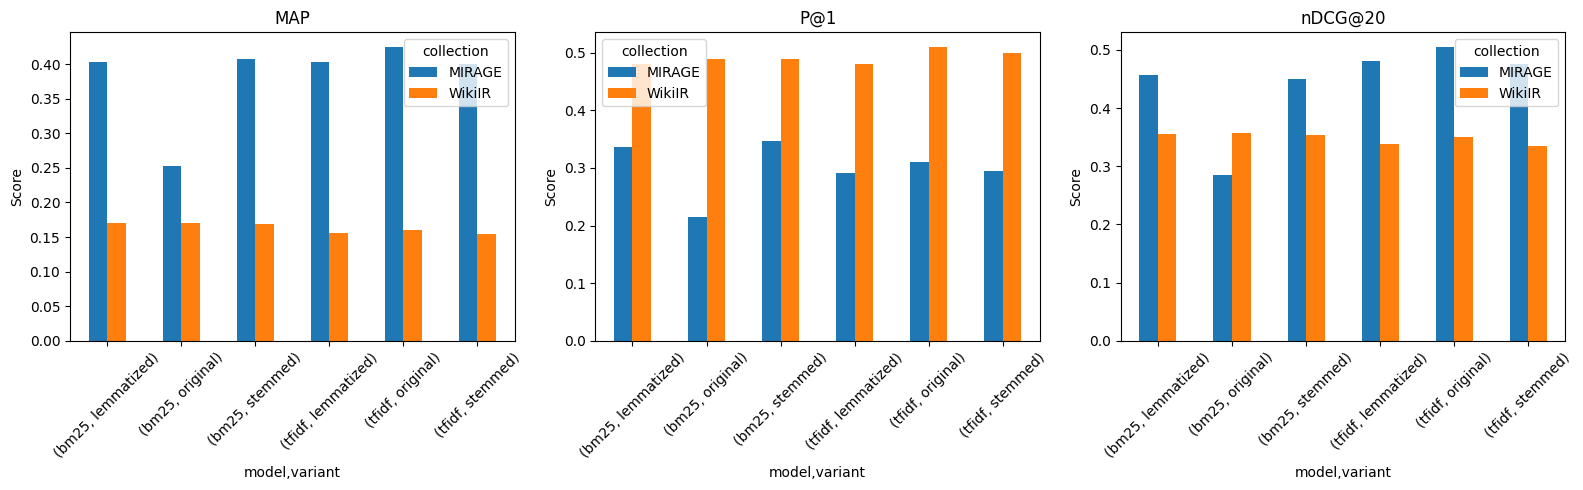

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["MAP", "P@1", "nDCG@20"]):
    pivot = comparison_df.pivot_table(index=["model", "variant"], columns="collection", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(metric)
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

## 8. Выводы

**Особенности MIRAGE:**
- Коллекция значительно меньше WikiIR (36.8k пассажей vs 369.7k документов), но с большим числом запросов (7560 vs ~100).
- Пассажи MIRAGE — это фрагменты Википедии, а не целые статьи. Средняя длина значительно короче.
- Каждый запрос имеет пул всего из 5 документов с бинарной разметкой (support=0/1).
- Из-за маленького пула документов задача ближе к переупорядочиванию короткого набора кандидатов, чем к поиску по большой коллекции.

**Результаты на MIRAGE:**
- Лучший результат показал `tfidf original`: MAP = 0.4249 и nDCG@20 = 0.5048.
- Для TF-IDF морфологическая обработка не помогла: и стемминг, и лемматизация немного ухудшили метрики относительно исходного текста.
- Для BM25 ситуация обратная: `bm25 original` оказался заметно хуже, а стемминг и лемматизация сильно улучшили результат.
- При этом даже после морфологической обработки лучшие варианты BM25 немного уступают `tfidf original` по MAP и nDCG@20.

**Сравнение с WikiIR:**
- На MIRAGE значения MAP и nDCG@20 выше, чем на WikiIR, что ожидаемо из-за маленького пула из 5 документов на запрос.
- На WikiIR лучше выглядит BM25, а на MIRAGE сильнее себя показал TF-IDF на исходных текстах.
- Значит, эффект модели и предобработки зависит от типа коллекции: для коротких пассажей и малого пула кандидатов простый TF-IDF может быть очень конкурентоспособным, а для более реалистичного поиска по большой коллекции BM25 оказывается устойчивее.